In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


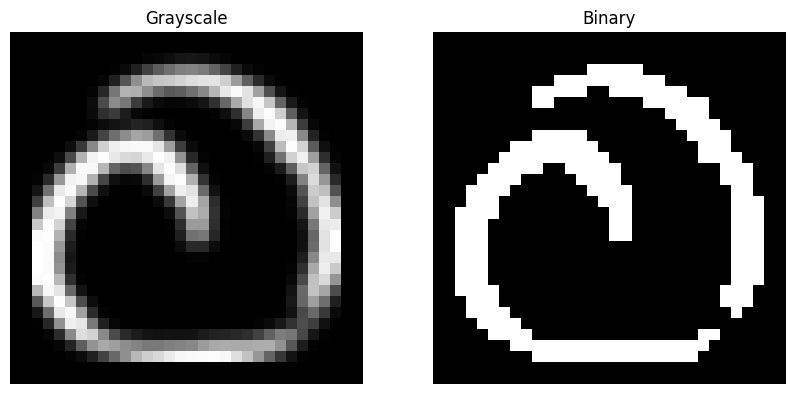

In [3]:
# convert to grayscale and then to binary
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0
img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show_images([gray, binary], ["Grayscale", "Binary"])

In [4]:
# Load the grayscale centered images
train_df = pd.read_csv("train.csv")

images = np.array([
    cv2.imread(f"train_gray_centered/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
    for _, row in tqdm(train_df.iterrows(), total=len(train_df))
])
labels = train_df["Category"].values
print(f"Loaded {len(images)} grayscale centered images with shape {images[0].shape}")


  0%|          | 0/17000 [00:00<?, ?it/s]

100%|██████████| 17000/17000 [00:05<00:00, 3225.92it/s]

Loaded 17000 grayscale centered images with shape (32, 32)


In [5]:
# train validation split
from sklearn.model_selection import train_test_split

# Flatten images for SVM
X = images.reshape(len(images), -1) // 255.0
y = labels

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=75, stratify=y)
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")

Training set: (12750, 1024), Validation set: (4250, 1024)


In [6]:
# add augmented features
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Define augmentation
datagen = ImageDataGenerator(
    rotation_range=10,        # rotate up to 10 degrees
    width_shift_range=0.1,    # shift horizontally up to 10%
    height_shift_range=0.1,   # shift vertically up to 10%
    zoom_range=0.1,           # zoom in/out up to 10%
    shear_range=0.1           # slight shear
)


# Reshape back to grayscale centered images for augmentation
X_train_img = X_train.reshape(-1, 32, 32, 1)

# Generate 3 batches of augmented data.
X_aug_list = []
y_aug_list = []
batches_generated = 0
batches_to_generate = 3

for X_batch, y_batch in datagen.flow(X_train_img, y_train, batch_size=len(X_train)):
    X_aug_list.append(X_batch.reshape(-1, 1024))  # flatten back
    y_aug_list.append(y_batch)
    batches_generated += 1
    if batches_generated >= batches_to_generate:
        break

# Combine original + augmented
X_combined = np.vstack([X_train, np.vstack(X_aug_list)])
y_combined = np.concatenate([y_train, np.concatenate(y_aug_list)])

print(f"Original: {len(X_train)} | Augmented: {len(X_combined)}")


2026-05-01 00:14:53.004722: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Original: 12750 | Augmented: 51000


In [7]:
from skimage.feature import hog
from skimage import morphology

# Skeletonization function
def skeletonize_images(image_flat):
    # Reshape back to 2D
    img_2d = image_flat.reshape(32, 32)
    
    # Convert from float (0.0-1.0) to uint8 (0-255)
    if img_2d.dtype != np.uint8:
        img_uint8 = (img_2d * 255.0).astype(np.uint8)
    else:
        img_uint8 = img_2d
        
    # Binarize using Otsu
    _, binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Convert to boolean for skimage
    boolean_image = binary > 0
    
    # Apply skeletonization
    skeleton = morphology.skeletonize(boolean_image)
    
    # Return as 2D uint8 array for HOG extraction
    return (skeleton * 255).astype(np.uint8)

# HOG feature extraction function
def extract_hog(images):
    features = []
    for img in images:
        fd = hog(img.reshape(32, 32), orientations=9,
                 pixels_per_cell=(4, 4), cells_per_block=(2, 2))
        features.append(fd)
    return np.array(features)



In [8]:
X_train_aug = X_combined
y_train_aug = y_combined

print("Extract HOG features from training data...")
X_train_hog_raw = extract_hog(X_combined)
print("Extract HOG features from validation data...")
X_val_hog_raw = extract_hog(X_val)

print(f"HOG feature shape for training data: {X_train_hog_raw.shape}")
print(f"HOG feature shape for validation data: {X_val_hog_raw.shape}")  


Extract HOG features from training data...
Extract HOG features from validation data...
HOG feature shape for training data: (51000, 1764)
HOG feature shape for validation data: (4250, 1764)


In [9]:
# Apply StandardScaler to HOG features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_hog_raw_scaled = scaler.fit_transform(X_train_hog_raw)
X_val_hog_raw_scaled = scaler.transform(X_val_hog_raw)


In [10]:
print("Extracting Skeleton wireframes...")
X_train_skel = np.array([skeletonize_images(img) for img in tqdm(X_combined)])
X_val_skel = np.array([skeletonize_images(img) for img in tqdm(X_val)])

# EXTRACT HOG FROM SKELETONS
print("Extracting HOG features from Skeletons...")
X_train_hog_skel = extract_hog(X_train_skel)
X_val_hog_skel = extract_hog(X_val_skel)

# SCALE SKELETON HOG FEATURES
print("Scaling Skeleton HOG features...")
scaler_skel = StandardScaler()
X_train_hog_skel_scaled = scaler_skel.fit_transform(X_train_hog_skel)
X_val_hog_skel_scaled = scaler_skel.transform(X_val_hog_skel)


Extracting Skeleton wireframes...


100%|██████████| 4250/4250 [00:00<00:00, 27881.33it/s]


Extracting HOG features from Skeletons...
Scaling Skeleton HOG features...


In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# TRAIN THE THREE MODELS
print("Training the three Expert SVMs...")
# Model trained on raw grayscale pixels from augmented data.
print("Training SVM on raw grayscale pixels...")
svm_raw = SVC(kernel="rbf", C=10, gamma=0.01)
svm_raw.fit(X_combined, y_combined)
print("Generate validation predictions for raw SVM...")
pred_raw = svm_raw.predict(X_val)
print(f"Raw SVM Accuracy:      {accuracy_score(y_val, pred_raw):.4f}")

Training the three Expert SVMs...
Training SVM on raw grayscale pixels...
Generate validation predictions for raw SVM...
Raw SVM Accuracy:      0.9553


In [ ]:

# HOG on Grayscale model (Edge directions)
print("Training SVM on HOG features from grayscale images...")
svm_hog = SVC(kernel="rbf", C=10, gamma=0.01)
svm_hog.fit(X_train_hog_raw_scaled, y_combined)
print("Generate validation predictions for HOG SVM...")
pred_hog = svm_hog.predict(X_val_hog_raw_scaled)
print(f"HOG SVM Accuracy:      {accuracy_score(y_val, pred_hog):.4f}")


In [ ]:

# HOG on Skeletons (Structural wireframe)
print("Training SVM on HOG features from skeletons...")
svm_skeleton = SVC(kernel="rbf", C=10, gamma=0.01)
svm_skeleton.fit(X_train_hog_skel_scaled, y_combined)
print("Generate validation predictions for Skeleton HOG SVM...")
pred_skeleton = svm_skeleton.predict(X_val_hog_skel_scaled)
print(f"Skeleton HOG SVM Accuracy: {accuracy_score(y_val, pred_skeleton):.4f}")


In [ ]:

# Majority voting algorithm
print("Start majority voting ensemble...")
final_ensemble_predictions = []
count = 0

for i in range(len(y_val)):
    # Gather the 3 votes for this specific image
    votes = [pred_raw[i], pred_hog[i], pred_skeleton[i]]
    
    # Pick the prediction that appears most often
    majority_vote = max(set(votes), key=votes.count)
    final_ensemble_predictions.append(majority_vote)
    count += 1
    if count % 500 == 0:
        print(f"Processed {count}/{len(y_val)} images for ensemble voting...")

# FINAL EVALUATION
print("========================================")
print(f"Raw SVM Accuracy:      {accuracy_score(y_val, pred_raw):.4f}")
print(f"HOG SVM Accuracy:      {accuracy_score(y_val, pred_hog):.4f}")
print(f"Skeleton SVM Accuracy: {accuracy_score(y_val, pred_skeleton):.4f}")
print(f"ENSEMBLE ACCURACY:     {accuracy_score(y_val, final_ensemble_predictions):.4f}")
print("========================================")

Steps:
- Train augmented SVM
- Apply StandardScalar to HOG
- Create skeleton function
- Create HOG without skeleton
- Create HOG with skeleton
- Create majority vote algorithm.